<h1>Project 3: Crystal Lattice</h1>

This project will focus on simulating connected structures as lattices of spheres connected by 
springs, observing energy in the system, and comparing integration methods. 

<H3>Imports</H3>

In [1]:
from vpython import *
import numpy as np
import matplotlib.pyplot as plt

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<h3>Constants</h3>

In [2]:
#Where mass is needed, use 1 for all values. Masses assumed equal
mass = 1.0
#Random seed for velocities for reproducability
seed = 3
np.random.seed(seed)

## Part 1: Undamped Spring Crystal Simulation

### Parameters

In [3]:
#Spring constant to be changed to suit visual
k = 10
#Time step for visualization
dt = 0.01
#Dimension for lattice structure (NxNxN)
N = 3
#Distance between each sphere in the structure
d = 1.0
#Value to keep limit inital velocities
v_max = 0.1

### Create Functions for Objects and Structures

In [4]:
#Total spheres for NxNxN object
N_spheres = N**3

#Each sphere will have a position, velocity, and force, each with a x, y, and z component
#Allows spheres to interact with eachother
positions  = np.zeros((N_spheres, 3))
velocities = np.zeros((N_spheres, 3))
forces     = np.zeros((N_spheres, 3))

#Function to return two np arrays for initial position and velocities
def initialize_v_p():
    #Loop through for each molecule
    idx = 0
    for i in range(N):
        for j in range(N):
            for k in range(N):
                #Position is a coordinate times the length between each molecule
                positions[idx] = [i * d, j * d, k * d]
                idx += 1
    
    #Initialize each sphere with a random limited  velocity, uniform used for varied values
    velocities = np.random.uniform(-v_max, v_max, (N_spheres, 3))
    return positions, velocities

In [5]:
#Create spheres from positions array
def create_spheres():
    vpython_spheres = []
    #For all spheres
    for i in range(N_spheres):
        #New sphere at proper position
        s = sphere(pos=vector(*positions[i]), radius=0.2, color=color.cyan)
        #List containing all spheres to return
        vpython_spheres.append(s)
    return vpython_spheres

In [6]:
#Function to get an array of all springs/connections between molecules
def get_springs(N):
    springs = []
    #Loop through every molecule
    for i in range(N):
        for j in range(N):
            for k in range(N):
                #Index for the current sphere
                current = i*N*N + j*N + k
                #Go through the right, upper, and forward neighbors, check to make sure
                #they are within the lattice, and add a spring for every new neighbor
                #Right neighbor
                if i+1 < N:
                    springs.append([current, (i+1)*N*N + j*N + k])
                #Upper neighbor
                if j+1 < N:
                    springs.append([current, i*N*N + (j+1)*N + k])
                #Forward neighbor
                if k+1 < N:
                    springs.append([current, i*N*N + j*N + (k+1)])
    #numpy array of springs returned
    return np.array(springs)

### Visualization of spheres with no interaction

In [7]:
#Create canvas
scene = canvas(title='Molecular Crystal', width=800, height=600)

#Initialize vpython spheres with velocities and positions
positions, velocities = initialize_v_p()
spheres = create_spheres()

#Better viewing as suggested
scene.autoscale = False
scene.center = vector(1, 1, 1) 
scene.range = 4

#No forces added yet
t = 0
dt = 0.01
#Run for 5 seconds
t_end = 5
while t < t_end:
    #Always set rate
    rate(100)
    #Simply update positions
    positions += velocities * dt
    #Visual update
    for i, s in enumerate(spheres):
        s.pos = vector(*positions[i])
    #Time progression
    t += dt

<IPython.core.display.Javascript object>

The spheres are all initialized into the right shape and we can see the molecules move in different directions and speeds. The molecules do not yet interact with each other and this is seen in the simulation

### Creating functions to track energy

In [8]:
#Input mass and velocity, return total kinetic energy using np.sum
def calc_kinetic_energy(velocities, mass):
    # 1/2 * m * v^2
    return 0.5 * mass * np.sum(velocities**2)

#Input the positions of all spheres, and the springs array
#Get the potential energy total with np.sum
def calc_potential_energy(positions, springs):
    # 1/2 * k * x^2, summed over all springs
    #Indeces for all from spheres
    i_idx = springs[:, 0]
    #Indeces for all to spheres
    j_idx = springs[:, 1]

    #Vector for connection between these spheres
    delta = positions[j_idx] - positions[i_idx]
    #Length of each connection by getting scalar
    lengths = np.linalg.norm(delta, axis=1)

    #Change in te spring length
    stretch = lengths - d
    #Sum across all spring lengths
    return 0.5 * k * np.sum(stretch**2)


In [9]:
#Input the poistions and springs arrays
#Return an array of forces between each connected molecule
def calc_forces(positions, springs):
    #Initialize array
    forces = np.zeros_like(positions)

    #From spheres
    i_idx = springs[:, 0]
    #To spheres
    j_idx = springs[:, 1]

    #Distance vector
    delta = positions[j_idx] - positions[i_idx]
    #Scalar for length of spring
    lengths = np.linalg.norm(delta, axis=1, keepdims=True)
    #Direction
    unit = delta / lengths
    #Magnitude, using hooke's law of F = k * x
    force_mag = k * (lengths - d)
    #Force vector as mag x direction
    force_vec = force_mag * unit

    #Accumulate forces at each index, both with i pulling and j pulling the other towards
    np.add.at(forces, i_idx,  force_vec)
    np.add.at(forces, j_idx, -force_vec)

    #numpy array of accumulated forces between every connected sphere
    return forces

### Simulation with new forces

Backwards euler integration is used to observe forces acting upon eachother in a new simulation.

<IPython.core.display.Javascript object>

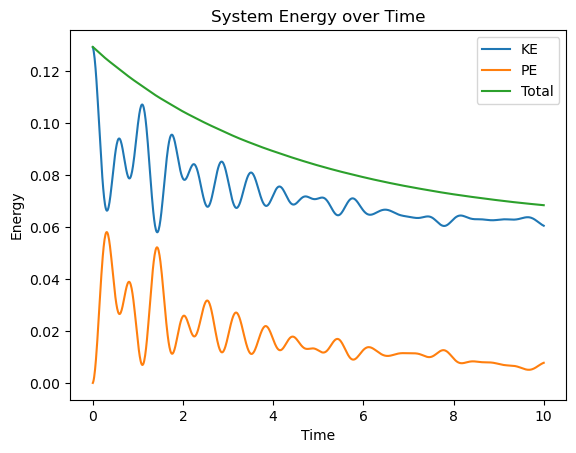

In [12]:
#Initialize springs, positions, velocities
positions, velocities = initialize_v_p()
springs = get_springs(N)

#Arrays for energy tracking and plotting
KE_list = []
PE_list = []
TE_list = []
t_list = []

#Create canvas and spheres
scene = canvas(title='Molecular Crystal', width=800, height=600)
#Create vpython spheres
vpython_spheres = create_spheres()
#For better viewing
scene.autoscale = False
scene.center = vector(1, 1, 1)
scene.range = 4

#Simulation loop with force
t = 0
#Run for 10 seconds
t_end = 10
dt = 0.01
#loop
while t < t_end:
    #Always set rate
    rate(100)
    
    #Calculate forces using function
    forces = calc_forces(positions, springs)
    
    #Backwards euler used first
    #New values used in equations
    new_pos = positions + velocities * dt
    new_forces = calc_forces(new_pos, springs)
    #Velocity and position calculated with new values
    #v + a(t+dt) * dt
    new_vel = velocities + (new_forces/mass) * dt  
    #x + v(t+dt) * dt
    new_pos = positions + new_vel * dt                           
    velocities = new_vel
    positions  = new_pos
    
    #Calculate energies, add to lists to plot
    KE = calc_kinetic_energy(velocities, mass)
    PE = calc_potential_energy(positions, springs)
    TE = KE + PE
    KE_list.append(KE)
    PE_list.append(PE)
    TE_list.append(TE)
    t_list.append(t)
    
    #Update visuals
    for i, s in enumerate(vpython_spheres):
        s.pos = vector(*positions[i])

    #Time progress
    t += dt

#Plot energy after simulation
plt.plot(t_list, KE_list, label='KE')
plt.plot(t_list, PE_list, label='PE')
plt.plot(t_list, TE_list, label='Total')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('System Energy over Time')
plt.legend()
plt.show()

Visually, we are able to verify this simulation as we can see these spheres move at their initial velocities but act upon eachother with different force and produce the spring-like behavior.

In the energy plot, we can see that we start with all of the total energy as kinetic energy. This makes sense, as our molecules are intialied with velocities and all of the springs have not changed length yet. As time increases, the potential and kinetic energy change, oscillating as would be expected in any spring system. Total energy is shown as the sum of both energies correctly. We can see it decrease slowly for this simulation, which goes against the conservation of energy. This is not as expected or hoped, but could be attributed to the integration method utilized of backwards euler

### Integration Methods

#### Backwards Euler

In [22]:
#Same as used previously, make as a function
def backwards_euler_update(positions, velocities):
    #Update positions
    new_pos = positions + velocities * dt
    #Forces calculated with new positions
    new_forces = calc_forces(new_pos, springs)
    #Velocities from new forces, F = m/a
    #v + a(t+dt) * dt
    new_vel = velocities + (new_forces/mass) * dt
    #x + v(t+dt) * dt
    new_pos = positions + new_vel * dt  
    #Return updated positions and velocities
    return new_pos, new_vel

#### Forwards Euler

In [23]:
#Forwards euler uses old values
def forwards_euler_update(positions, velocities):
    #Calculate force
    forces = calc_forces(positions, springs)
    #Update velocity and position based on current values
    #v + a(t) * dt
    new_vel = velocities + (forces/mass) * dt
    #x + v(t) * dt
    new_pos = positions + velocities * dt 
    #Return updated positions and velocities
    return new_pos, new_vel

#### Trapezoid

In [24]:
#Trapezoid takes and average of the new and the old values
def trapezoid_update(positions, velocities):
    #Calculate force
    forces = calc_forces(positions, springs)
    #New position to get new force
    new_pos_est = positions + velocities * dt
    #New force
    new_forces  = calc_forces(new_pos_est, springs)
    #Update velocity and position on averages
    #x + 0.5*(v(t) + v(t + dt))
    new_vel = velocities + 0.5 * (forces + new_forces) / mass * dt
    #x + 0.5*(v(t) + v(t + dt))
    new_pos = positions + 0.5 * (velocities + new_vel) * dt
    #Return updated position and velocity
    return new_pos, new_vel

### Integration Methods Verification

Create a new function for running specific integration methods with a specified t and dt

In [25]:
def integration_ver(method, time, time_step):
    #Initialize
    positions, velocities = initialize_v_p()
    springs = get_springs(N)
    
    #Storage for energy tracking
    KE_list = []
    PE_list = []
    TE_list = []
    t_list = []
    
    #Simulation loop
    t = 0
    #Run for specified time
    t_end = time
    #Set dt everywhere
    global dt 
    dt = time_step
    while t < t_end:
        rate(100)
        
        #Choose the correct method
        #Backwards
        if method == 1:
            positions, velocities = backwards_euler_update(positions, velocities)
        #Forwards
        elif method == 2:
            positions, velocities = forwards_euler_update(positions, velocities)
        #Trapezoid
        elif method == 3:
            positions, velocities = trapezoid_update(positions, velocities)
        #Exit
        else:
            break
        
        #Track energy
        KE = calc_kinetic_energy(velocities, mass)
        PE = calc_potential_energy(positions, springs)
        TE = KE + PE
        KE_list.append(KE)
        PE_list.append(PE)
        TE_list.append(TE)
        t_list.append(t)

        #Time progression
        t += dt
    
    #Plot energy after simulation
    plt.plot(t_list, KE_list, label='KE')
    plt.plot(t_list, PE_list, label='PE')
    plt.plot(t_list, TE_list, label='Total')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy (J)')
    plt.title('System Energy over Time')
    plt.legend()
    plt.show()

#### Backwards Euler

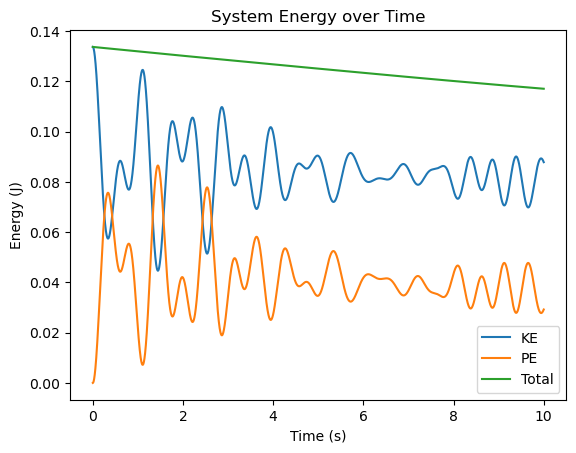

In [26]:
#Backwards Euler
#Run for 10 seconds
#Time step = 0.001
integration_ver(1, 10, 0.001)

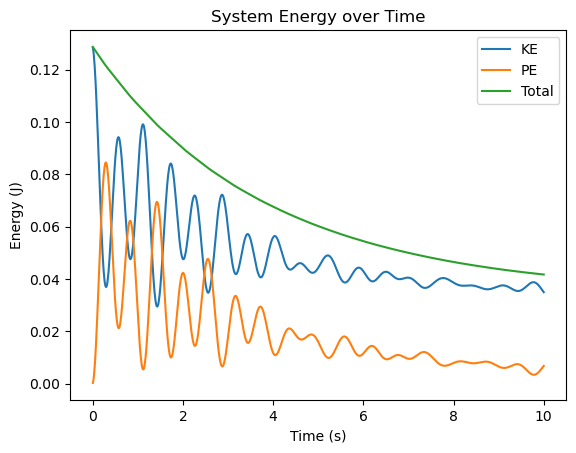

In [27]:
#Backwards Euler
#Run for 10 seconds
#Time step = 0.01
integration_ver(1, 10, 0.01)

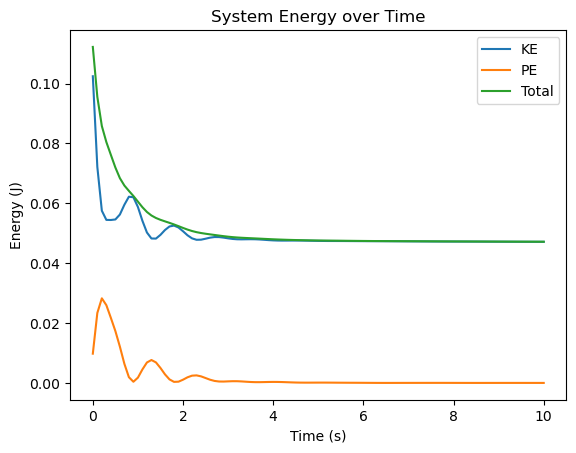

In [28]:
#Backwards Euler
#Run for 10 seconds
#Time step = 0.1
integration_ver(1, 10, 0.1)

#### Backwards Euler Analysis

In the first graph, with a very small time step of 0.001, we can see a small linear decrease in total energy as time goes on. The kinetic and potential energies still oscillate, and our total energy still represents the sum. With a time step of 0.01, we can see that this decrease becomes more of a quadratic relationship, with the energies appearing to flatten out towards the end. At a large time step of 0.1, we have a steep quadratic curve where the total energy levels out after about 3 seconds. At this point, the system is entirely kinetic energy.

This shows that since backwards Euler uses only the new accleration and velocity in its calculations, it will produce an error in its calculations. With a small time step, we are updating frequently enough to where energy is slowly lost. With the large time steps, however, the simulation is no longer stable and we lose energy much faster

#### Forwards Euler

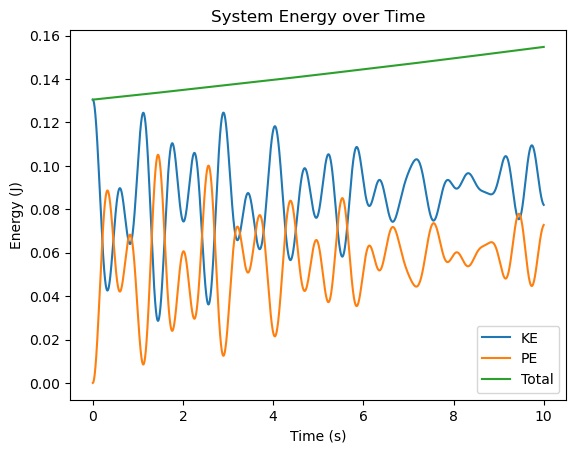

In [29]:
#Forwards Euler
#Run for 10 seconds
#Time step = 0.001
integration_ver(2, 10, 0.001)

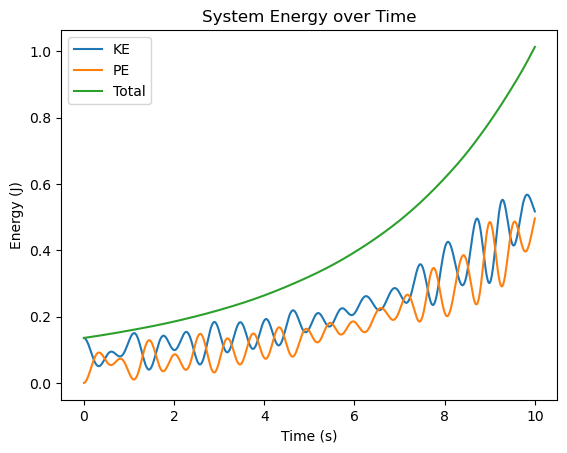

In [30]:
#Forwards Euler
#Run for 10 seconds
#Time step = 0.01
integration_ver(2, 10, 0.01)

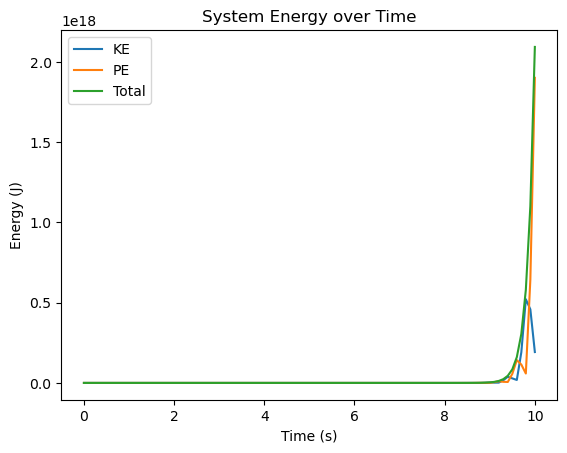

In [31]:
#Forwards Euler
#Run for 10 seconds
#Time step = 0.1
integration_ver(2, 10, 0.1)

#### Forwards Euler Analysis

In the first graph, with a very small time step of 0.001, we can see a small linear increase in total energy as time goes on. The kinetic and potential energies still oscillate, and our total energy still represents the sum. With a time step of 0.01, we can see that this increase become quadratic and continuing to increase while the kintic and potential energies oscillate. At a large time step of 0.1, we have a steep quadratic curve at about 9 seconds where the total energy reaches very large levels and becomes unstable.

#### Trapezoid

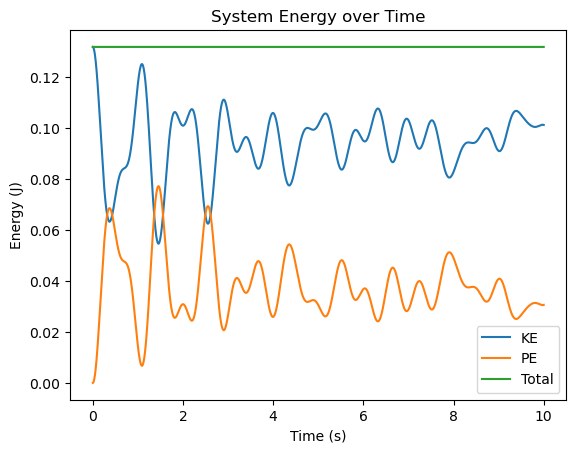

In [32]:
#Trapezoid
#Run for 10 seconds
#Time step = 0.001
integration_ver(3, 10, 0.001)

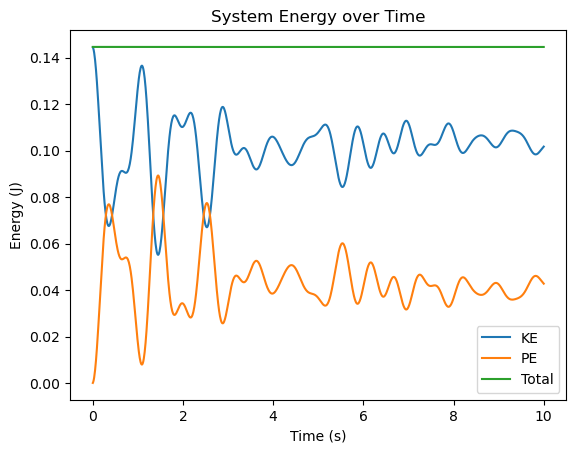

In [33]:
#Trapezoid
#Run for 10 seconds
#Time step = 0.01
integration_ver(3, 10, 0.01)

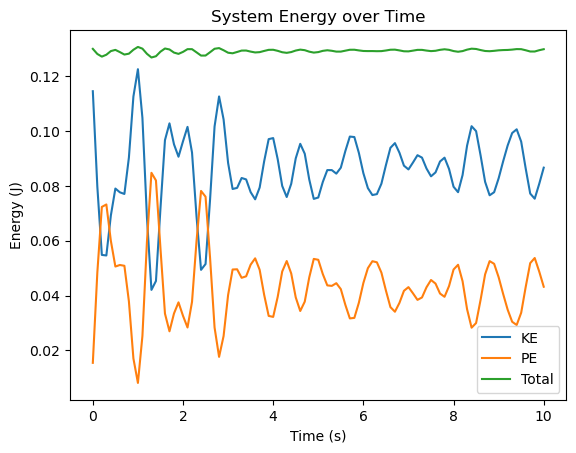

In [34]:
#Trapezoid
#Run for 10 seconds
#Time step = 0.1
integration_ver(3, 10, 0.1)

Trapezoid is shown to be the most stable of the integration methods as it uses both the current and next state acclerations and velocities to get the new positions and velocities. Regardless of time step, we can see that total energy remains stable, with the lowest time step values of 0.001 and 0.01 showing almost no variation in total energy. Kinetic and potential energy once again oscillate as we expect.

## Part 2: Damped Spring Crystal Simulation

We will want to run the same simulations as before but with a damping coefficient applied

In [35]:
#Damping coefficient
c = 0.1

#### Visualization

Use trapezoid for the most stable method. Apply the damping coefficient to all velocities used

<IPython.core.display.Javascript object>

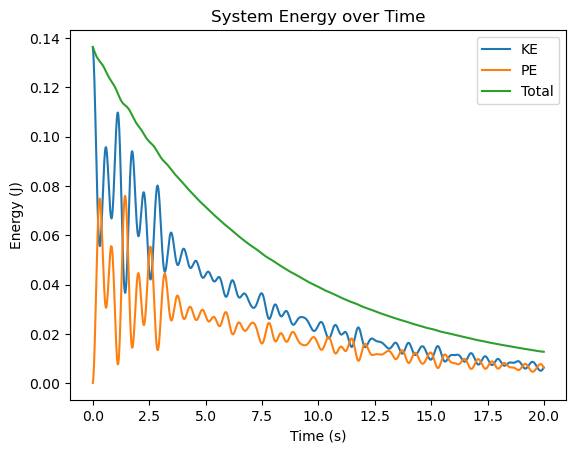

In [37]:
#Initialize
positions, velocities = initialize_v_p()
springs = get_springs(N)

#Storage for energy tracking
KE_list = []
PE_list = []
TE_list = []
t_list = []

#Create canvas and spheres
scene = canvas(title='Molecular Crystal with Damping', width=800, height=600, background=color.black)
vpython_spheres = create_spheres()
scene.autoscale = False
scene.center = vector(1, 1, 1)
scene.range = 4

#Simulation loop
t = 0
t_end = 20  # seconds
dt = 0.01
while t < t_end:
    rate(100)
    
    #Trapezoid
    forces = calc_forces(positions, springs)
    damping = -c * velocities                          
    
    new_pos_est = positions + velocities * dt
    new_forces  = calc_forces(new_pos_est, springs)
    new_vel_est = velocities + (forces + damping) / mass * dt
    new_damping = -c * new_vel_est                     
    
    new_vel = velocities + 0.5 * ((forces + damping) + (new_forces + new_damping)) / mass * dt
    new_pos = positions + 0.5 * (velocities + new_vel) * dt                        
    velocities = new_vel
    positions  = new_pos
    
    #Track energy
    KE = calc_kinetic_energy(velocities, mass)
    PE = calc_potential_energy(positions, springs)
    TE = KE + PE
    KE_list.append(KE)
    PE_list.append(PE)
    TE_list.append(TE)
    t_list.append(t)
    
    #Update visuals
    for i, s in enumerate(vpython_spheres):
        s.pos = vector(*positions[i])
    
    t += dt

#Plot energy after simulation
plt.plot(t_list, KE_list, label='KE')
plt.plot(t_list, PE_list, label='PE')
plt.plot(t_list, TE_list, label='Total')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('System Energy over Time')
plt.legend()
plt.show()

Visually, we can see that although the molecules start with the same velocities, they lose velocity much quicker. The molecules become stable at the end as well much quicker. It is a significant difference from the previous visual simulations.

In this damped simulation, a time step of 0.01 is used and it is run for 20 seconds. Other initial conditions are kept the same for easy comparison to our undamped scenario. We can see that even using our most stable integration method of trapezoid method, we still get much different behavior. The total energy is no longer constant with time. There is an approximately exponential decrease, which aligns with our expectations with damping. The kinetic and potential energies oscillate but decrease as well, lining up with the total energy. The graph is similar to backwards euler as backwards euler uses smaller velocities in each update, and we are applying our damping coefficient to the velocities of the different molecules to decrease the velocities.